**Loading the Data**

In [1]:
from datasets import load_dataset

#Load Dataset in chunks
#Too big to load all at once
dataset = load_dataset("allenai/WildChat-1M", streaming=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

In [2]:
from itertools import islice
import pandas as pd

#Put the first 50000 rows in a df - Can be adjusted
sample = list(islice(dataset["train"], 50000))
df = pd.DataFrame(sample)

In [3]:
df.head()

,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020589135237969458, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,[{'content': 'Crea una imagen de una mujer cor...,2,Spanish,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.007170863449573517, 'in...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36c...,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8',..."
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,2023-04-09 00:04:52+00:00,"[{'content': 'Old age PT hx of DM, HTN, dyslip...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0002258022577734664, 'i...",False,False,Mecca Region,Saudi Arabia,8133108d1c433c180c6be8302dc5a6681f2bec980190a1...,"{'accept-language': 'en-US,en;q=0.9', 'user-ag..."
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,2023-04-09 00:06:29+00:00,[{'content': 'calcula la mediana de followers:...,1,Catalan,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0003390185011085123, 'i...",False,False,Barcelona,Spain,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,"{'accept-language': 'es,es-ES;q=0.9,en;q=0.8,e..."
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,2023-04-09 00:06:49+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020642601884901524, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."


In [4]:
#All data analyzed is in April 2023
df.timestamp.describe()

,timestamp
count,50000
mean,2023-04-20 16:24:35.880639744+00:00
min,2023-04-09 00:02:53+00:00
25%,2023-04-15 15:17:09.750000128+00:00
50%,2023-04-21 03:11:35+00:00
75%,2023-04-26 00:35:39.249999872+00:00
max,2023-04-30 17:32:36+00:00


**Data Preprocessing**

In [5]:
#Don't need all the columns
df_subset = df[['conversation_hash', 'model', 'conversation', 'turn', 'language']]

In [6]:
#Only want to look at English conversations
df_subset = df_subset[df_subset['language'] == 'English']
df_subset.shape

(23797, 5)

In [7]:
#Want to get rid of exact duplicate conversations
df_unique = df_subset.drop_duplicates(subset=["conversation_hash"]).reset_index(drop = True)
df_unique.shape

(23698, 5)

**How Many Turns do Users Often Ask Questions in ChatGPT?**

In [8]:
#Most conversations have very few turns
df_unique.turn.value_counts()

,count
turn,
1,12478
2,4231
3,2186
4,1294
5,827
6,625
7,431
8,340
9,290


In [9]:
df_unique.turn.describe()

,turn
count,23698.000000
mean,2.646215
std,3.094998
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,55.000000


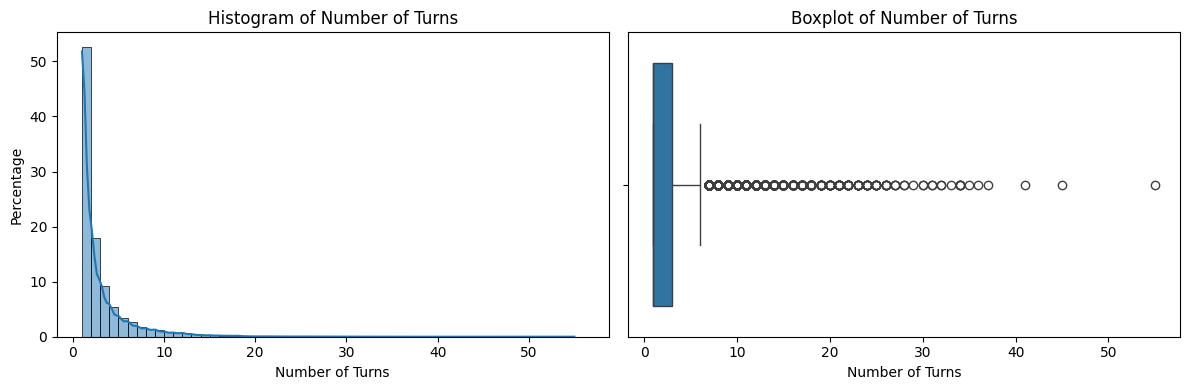

Lower Whisker: 1
Q1: 1.0
Median: 1.0
Q3: 3.0
Upper Whisker: 6


In [10]:
#Histogram and Boxplot of number of turns for conversations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the figure and axes for the plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of the 'turn' column
sns.histplot(df_unique['turn'], bins=range(1, df_unique['turn'].max() + 2), kde=True, stat = 'percent', ax=axes[0])
axes[0].set_title('Histogram of Number of Turns')
axes[0].set_xlabel('Number of Turns')
axes[0].set_ylabel('Percentage')

# Boxplot of the 'turn' column
sns.boxplot(x=df_unique['turn'], ax=axes[1])
axes[1].set_title('Boxplot of Number of Turns')
axes[1].set_xlabel('Number of Turns') # Changed to xlabel for horizontal boxplot

# Calculate statistics for the boxplot
stats = df_unique['turn'].describe()
median = stats['50%']
q1 = stats['25%']
q3 = stats['75%']

# Calculate whiskers (1.5 * IQR from Q1 and Q3, within data range)
iqr = q3 - q1
lower_whisker = df_unique['turn'][df_unique['turn'] >= q1 - 1.5 * iqr].min()
upper_whisker = df_unique['turn'][df_unique['turn'] <= q3 + 1.5 * iqr].max()

plt.tight_layout()
plt.show()

print('Lower Whisker:', lower_whisker)
print('Q1:', q1)
print('Median:', median)
print('Q3:', q3)
print('Upper Whisker:', upper_whisker)

In [11]:
#Filter rows with only 1 turn (they don't have any info about users sentiment towards response)
df_unique = df_unique[df_unique['turn'] > 1]
df_unique.shape

(11220, 5)

In [12]:
#We will use 4 for the turn threshold
# Four or less turns we will define as a small number of turns, and five or more as a large number of turns
turn_threshold = 4
print('Turn Threshold:', turn_threshold)
df_unique['turn_category'] = df_unique['turn'].apply(lambda x: 'small_turns' if x <= turn_threshold else 'large_turns')
print(df_unique['turn_category'].value_counts())

Turn Threshold: 4
turn_category
small_turns    7711
large_turns    3509
Name: count, dtype: int64


In [13]:
#Make each row a different turn instead of a different conversation
df_turns = df_unique.explode("conversation").reset_index(drop = True)
df_turns.head(15)

,conversation_hash,model,conversation,turn,language,turn_category
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"{'content': 'Let A, B, and C be events with P...",7,English,large_turns
1,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'To find the smallest possible val...,7,English,large_turns
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Question 4 options: Let A and B b...,7,English,large_turns
3,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'To find the smallest possible val...,7,English,large_turns
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Alice and Bob share binary commun...,7,English,large_turns
5,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'We can solve this by finding the ...,7,English,large_turns
6,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Alice and Bob share a noisy commu...,7,English,large_turns
7,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'In order for Alice to receive the...,7,English,large_turns
8,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Answer True or False to the follo...,7,English,large_turns
9,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"{'content': 'False. If P[A | B] = 1, it means...",7,English,large_turns


In [14]:
#Creates a column for the respondant's role (user or assistant)
df_turns['role'] = df_turns['conversation'].apply(lambda x: x['role'])

In [15]:
display(df_turns.head())
print(df_turns.shape)

,conversation_hash,model,conversation,turn,language,turn_category,role
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"{'content': 'Let A, B, and C be events with P...",7,English,large_turns,user
1,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'To find the smallest possible val...,7,English,large_turns,assistant
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Question 4 options: Let A and B b...,7,English,large_turns,user
3,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'To find the smallest possible val...,7,English,large_turns,assistant
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,{'content': 'Alice and Bob share binary commun...,7,English,large_turns,user


(100464, 7)


In [16]:
#Make the conversation field just be the text of the conversation (the content in the dictionary)
df_turns['conversation'] = df_turns['conversation'].apply(lambda x: x['content'])

In [17]:
df_turns.head()

,conversation_hash,model,conversation,turn,language,turn_category,role
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"Let A, B, and C be events with\n\nProb[A] = 0....",7,English,large_turns,user
1,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,To find the smallest possible value for P[A ∩ ...,7,English,large_turns,assistant
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user
3,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,To find the smallest possible value of P[A | B...,7,English,large_turns,assistant
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user


In [18]:
#Don't need sentiment analysis for the tone of the assistant's conversation, only want the user's to learn how they feel about the assistant/LLM's response
df_turns = df_turns[df_turns['role'] == 'user']

df_turns.shape

(50232, 7)

In [19]:
#Create a turn counter column for each convesation by the user
df_turns['user_turn'] = df_turns.groupby('conversation_hash').cumcount()

In [20]:
df_turns.head()

,conversation_hash,model,conversation,turn,language,turn_category,role,user_turn
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"Let A, B, and C be events with\n\nProb[A] = 0....",7,English,large_turns,user,0
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user,1
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user,2
6,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share a noisy communication chan...,7,English,large_turns,user,3
8,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Answer True or False to the following claim.\n...,7,English,large_turns,user,4


In [21]:
import copy
#Create a deep copy that retains the first turn for the user for grouping question types with responses later
df_turns_copy = copy.deepcopy(df_turns)

#Don't include conversations with only 1 turn
#They doesn't have any information about the user's reponse to the LLM's answer
df_turns = df_turns[df_turns['user_turn'] >= 1]
df_turns = df_turns.reset_index(drop = True)
df_turns.shape

(39012, 8)

In [22]:
df_turns.head()

,conversation_hash,model,conversation,turn,language,turn_category,role,user_turn
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user,1
1,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user,2
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share a noisy communication chan...,7,English,large_turns,user,3
3,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Answer True or False to the following claim.\n...,7,English,large_turns,user,4
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"calculate the payment, interest,etc for a mort...",7,English,large_turns,user,5


**How Satisfied are Users with long vs. short Conversations?**

In [23]:
#We'll use VADER to analyze sentiment polarity and use this as a proxy for user satisfaction
#Vader works well because this is short, informal text that contains slang/emojis,
#and we're only analyzing English text
%pip install nltk

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer

#Create VADER analyzer
sia = SentimentIntensityAnalyzer()

In [25]:
#Find the compound scores for each turn by the user that's not their first turn
#Positive score is positive sentiment, negative score is negative sentiment, and score around 0 is neutral sentiment
df_turns['compound_score'] = df_turns['conversation'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [26]:
df_turns.head()

,conversation_hash,model,conversation,turn,language,turn_category,role,user_turn,compound_score
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user,1,0.3400
1,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user,2,0.4767
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share a noisy communication chan...,7,English,large_turns,user,3,0.7399
3,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Answer True or False to the following claim.\n...,7,English,large_turns,user,4,0.4215
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"calculate the payment, interest,etc for a mort...",7,English,large_turns,user,5,0.4588


In [27]:
#Only need these columns currently
df_turns_agg = df_turns.groupby(['conversation_hash', 'model', 'turn_category'])['compound_score'].mean().reset_index()
df_turns_agg.head()

,conversation_hash,model,turn_category,compound_score
0,0007c54d678bf0476f5e8eb8585cea7d,gpt-4-0314,small_turns,0.571900
1,0017269430a204528fa7446fe4d58802,gpt-3.5-turbo-0301,small_turns,0.680800
2,001ab6295ffc117b136cd842d858c388,gpt-3.5-turbo-0301,large_turns,0.019771
3,001bc09aac7afa1b13df57e2fb65913c,gpt-3.5-turbo-0301,small_turns,0.000000
4,0024c8bdc92498f73dd1d534562a4ee1,gpt-3.5-turbo-0301,small_turns,0.000000


/tmp/ipython-input-1014510022.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


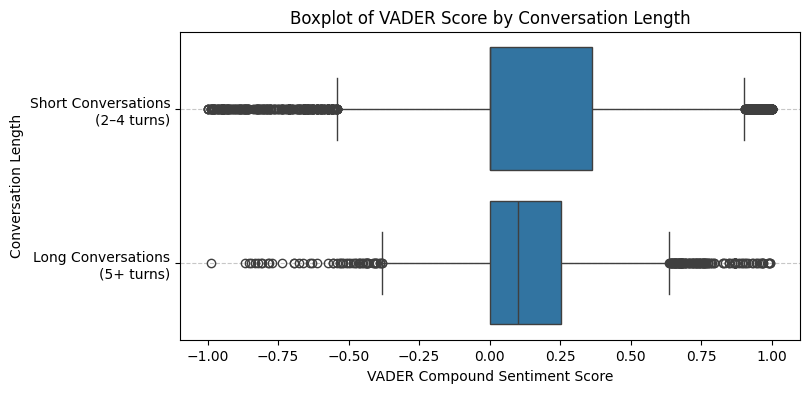

In [28]:
#Boxplot of VADER scores for small number of turns vs large number of turns
plt.figure(figsize=(8, 4))
ax = sns.boxplot(x = 'compound_score', y = 'turn_category', data = df_turns_agg)
plt.title('Boxplot of VADER Score by Conversation Length')
plt.xlabel('VADER Compound Sentiment Score')
plt.ylabel('Conversation Length')
ax.set_yticklabels([
    'Short Conversations\n(2–4 turns)',
    'Long Conversations\n(5+ turns)'
])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

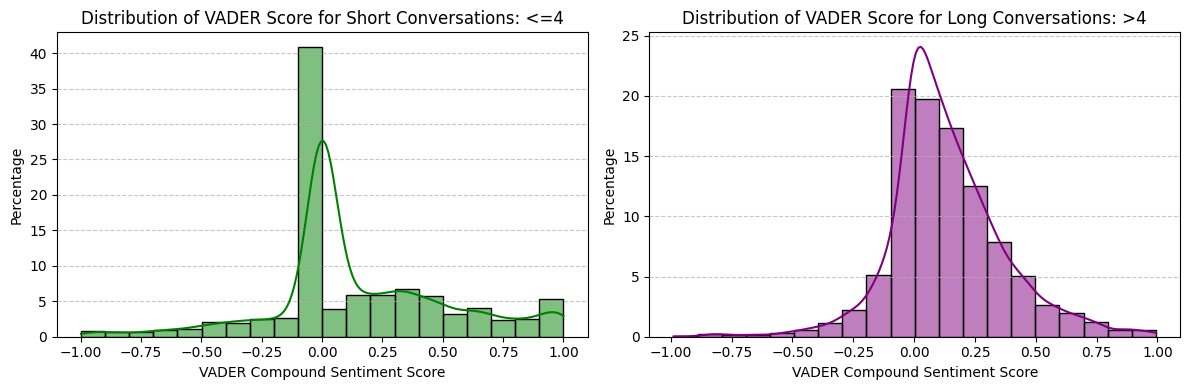

In [29]:
#Histogram of VADER scores for small number of turns vs large number of turns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot histogram for distribution of VADER scores for short conversations
sns.histplot(data=df_turns_agg[df_turns_agg['turn_category'] == 'small_turns'],
             x='compound_score', kde=True, stat='percent', binwidth=0.1, color='green', ax=axes[0])
axes[0].set_title(f'Distribution of VADER Score for Short Conversations: <=4')
axes[0].set_xlabel('VADER Compound Sentiment Score')
axes[0].set_ylabel('Percentage')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot histogram for distribution of VADER scores for long conversations
sns.histplot(data=df_turns_agg[df_turns_agg['turn_category'] == 'large_turns'],
             x='compound_score', kde=True, stat='percent', binwidth=0.1, color='purple', ax=axes[1])
axes[1].set_title(f'Distribution of VADER Score for Long Conversations: >4')
axes[1].set_xlabel('VADER Compound Sentiment Score')
axes[1].set_ylabel('Percentage')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# Expanded summary statistics for conversation length vs VADER scores
stats_summary = df_turns_agg.groupby('turn_category')['compound_score'].agg([
    'count',
    'mean',
    'median',
    'std',
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75)),
    ('lower whisker', lambda x: x.quantile(0.25) - 1.5 * (x.quantile(0.75) - x.quantile(0.25))),
    ('upper whisker', lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))
])

print(stats_summary.sort_values('mean', ascending=False))

               count      mean    median       std  25%      75%  \
turn_category                                                      
small_turns     7711  0.152626  0.000000  0.376880  0.0  0.36120   
large_turns     3509  0.134496  0.098925  0.235053  0.0  0.25444   

               lower whisker  upper whisker  
turn_category                                
small_turns         -0.54180         0.9030  
large_turns         -0.38166         0.6361  


In [31]:
from scipy import stats

# Extract sentiment scores for each category
small_turns_sentiment = df_turns_agg[df_turns_agg['turn_category'] == 'small_turns']['compound_score']
large_turns_sentiment = df_turns_agg[df_turns_agg['turn_category'] == 'large_turns']['compound_score']

# Perform Mann-Whitney U test
u_statistic, p_value = stats.mannwhitneyu(small_turns_sentiment, large_turns_sentiment, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {u_statistic:.2f}")
print(f"P-value: {p_value:.3e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis.\nThere is a statistically significant difference in VADER compound sentiment scores between conversations with a small number of turns and those with a large number of turns.")
else:
    print(f"\nSince the p-value ({p_value:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.\nThere is no statistically significant difference in VADER compound sentiment scores between conversations with a small number of turns and those with a large number of turns.")

Mann-Whitney U Statistic: 12971573.50
P-value: 3.824e-04

Since the p-value (3.824e-04) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in VADER compound sentiment scores between conversations with a small number of turns and those with a large number of turns.


**What type of questions are users most and least satisfied with after receiving an answer to?**

In [32]:
#Copy that includes first turn questions
df_turns_copy.head()

#Will use questions from original turn and map to vader scores from user's response/subsequent turn
#First turns necessary to use again, last turns won't be necessary now

,conversation_hash,model,conversation,turn,language,turn_category,role,user_turn
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"Let A, B, and C be events with\n\nProb[A] = 0....",7,English,large_turns,user,0
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user,1
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user,2
6,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share a noisy communication chan...,7,English,large_turns,user,3
8,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Answer True or False to the following claim.\n...,7,English,large_turns,user,4


In [33]:
#Recreate the polarity scores for conversations with the first turn included
df_turns_copy['compound_score'] = df_turns_copy['conversation'].apply(lambda x: sia.polarity_scores(x)['compound'])

df_turns_copy.head()

,conversation_hash,model,conversation,turn,language,turn_category,role,user_turn,compound_score
0,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,"Let A, B, and C be events with\n\nProb[A] = 0....",7,English,large_turns,user,0,0.3400
2,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Question 4 options:\nLet A and B be events wit...,7,English,large_turns,user,1,0.3400
4,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share binary communication chann...,7,English,large_turns,user,2,0.4767
6,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Alice and Bob share a noisy communication chan...,7,English,large_turns,user,3,0.7399
8,aa7c3f49343e097be66442288abd1dac,gpt-4-0314,Answer True or False to the following claim.\n...,7,English,large_turns,user,4,0.4215


In [34]:
#Only include necessary columns
df_turns_copy_agg = df_turns_copy[['conversation_hash', 'conversation', 'turn', 'user_turn', 'compound_score']]
df_turns_copy_agg.head()

,conversation_hash,conversation,turn,user_turn,compound_score
0,aa7c3f49343e097be66442288abd1dac,"Let A, B, and C be events with\n\nProb[A] = 0....",7,0,0.3400
2,aa7c3f49343e097be66442288abd1dac,Question 4 options:\nLet A and B be events wit...,7,1,0.3400
4,aa7c3f49343e097be66442288abd1dac,Alice and Bob share binary communication chann...,7,2,0.4767
6,aa7c3f49343e097be66442288abd1dac,Alice and Bob share a noisy communication chan...,7,3,0.7399
8,aa7c3f49343e097be66442288abd1dac,Answer True or False to the following claim.\n...,7,4,0.4215


In [35]:
# Sort by conversation and turn number
df_turns_copy_agg = df_turns_copy_agg.sort_values(['conversation_hash', 'user_turn'])

# Shift compound_score down for each conversation
#Turn 1 receives the compound score for the turn 2 conversation - sentiment based on turn 1's question
df_turns_copy_agg['compound_score_shifted'] = df_turns_copy_agg.groupby('conversation_hash')['compound_score'].shift(-1)

# Drop the last turn in the conversation (NaN after shift)
df_turns_copy_agg = df_turns_copy_agg[df_turns_copy_agg['compound_score_shifted'].notna()]

# Drop the old compound_score column
df_turns_copy_agg = df_turns_copy_agg.drop(columns='compound_score')
df_turns_copy_agg = df_turns_copy_agg.reset_index(drop=True)

df_turns_copy_agg.head()


,conversation_hash,conversation,turn,user_turn,compound_score_shifted
0,0007c54d678bf0476f5e8eb8585cea7d,how do i fall asleep better?,2,0,0.5719
1,0017269430a204528fa7446fe4d58802,foreach (var da in WorkflowList)\n ...,4,0,0.6808
2,0017269430a204528fa7446fe4d58802,foreach (var da in WorkflowList)\n{\nforeach (...,4,1,0.6808
3,0017269430a204528fa7446fe4d58802,foreach (var da in WorkflowList)\n{\nforeach (...,4,2,0.6808
4,001ab6295ffc117b136cd842d858c388,Let's play a game,15,0,0.4019


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

#Remove common words
custom_noise = ['make', 'like', 'tell', 'want', 'just', 'way', 'dan', 'don', 'using', 'use']
# Combine with standard english stops
my_stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_noise))

# Converts Pandas Series of conversations to a list of strings
texts = df_turns_copy_agg['conversation'].tolist()

# Converts text to a vector and then a feature matrix
#Consider top 2000 words (1 word or 2 word grams), word can't be in more than 20% of the turns, and must be in at least five turns to be eligible
#Trying to find granular clusters that are categorized by unique words
vectorizer = TfidfVectorizer(max_features=2000, stop_words=my_stop_words, ngram_range=(1, 2), max_df = 0.2, min_df = 5)
X = vectorizer.fit_transform(texts)


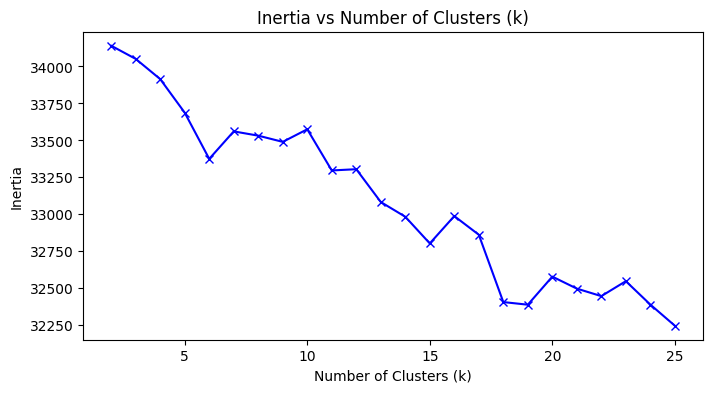

In [37]:
#Find "Elbow" to determine the optimal number of clusters for KMeans
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 26)

#Run KMeans with the specified number of clusters and find the intertia
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

#Plot intertia vs number of clusters
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Inertia vs Number of Clusters (k)')
plt.show()

k=2, Score: 0.0524
k=3, Score: 0.0435
k=4, Score: 0.0446
k=5, Score: 0.0510
k=6, Score: 0.0552
k=7, Score: 0.0473
k=8, Score: 0.0425
k=9, Score: 0.0517
k=10, Score: 0.0490
k=11, Score: 0.0549
k=12, Score: 0.0532
k=13, Score: 0.0525
k=14, Score: 0.0548
k=15, Score: 0.0552
k=16, Score: 0.0560
k=17, Score: 0.0553
k=18, Score: 0.0568
k=19, Score: 0.0603
k=20, Score: 0.0607
k=21, Score: 0.0563
k=22, Score: 0.0593
k=23, Score: 0.0568
k=24, Score: 0.0593
k=25, Score: 0.0628


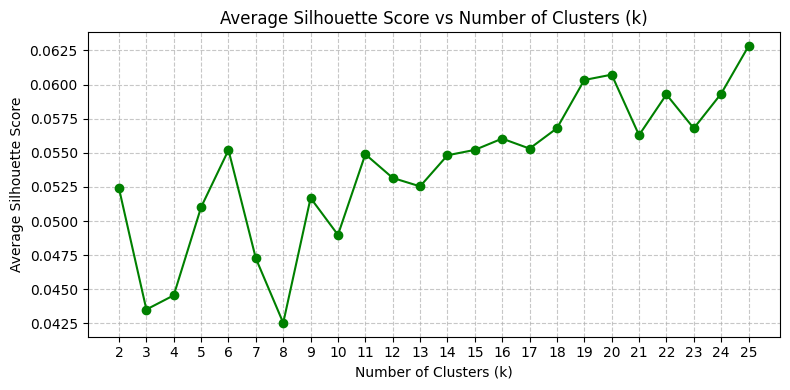

In [38]:
#Find Silhouette Score for each number of clusters for KMeans
#Higher Silhouette Score = better clustering
from sklearn.metrics import silhouette_score

k_range = range(2, 26)
silhouette_scores = []

#Run KMeans with the specified number of clusters and find the silhouette score
for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Score: {score:.4f}")

#Plot Silhouette Score vs number of clusters
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='green', linestyle='-')
plt.title('Average Silhouette Score vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Best combination for elbow and number of clusters around k = 20 clusters

In [39]:
# 20 clusters looks best based on combination of Silhouette Scores and Inertia plot, but could be adjusted
num_topics = 20
kmeans = KMeans(n_clusters=num_topics, random_state=42, n_init = 50)
#Topic is the cluster each turn is assigned to
df_turns_copy_agg['topic'] = kmeans.fit_predict(X)

#Get mean vader scores for each clusuter
df_topics = df_turns_copy_agg.groupby('topic')['compound_score_shifted'].mean().reset_index().sort_values('compound_score_shifted')
print(df_topics)


    topic  compound_score_shifted
11     11                0.081701
3       3                0.094056
18     18                0.108240
13     13                0.109438
17     17                0.119225
8       8                0.129554
9       9                0.142844
14     14                0.147752
0       0                0.148313
5       5                0.165903
12     12                0.171467
7       7                0.179247
19     19                0.188636
2       2                0.199973
15     15                0.223863
4       4                0.224498
1       1                0.243060
10     10                0.249322
6       6                0.256298
16     16                0.279500


In [40]:
terms = vectorizer.get_feature_names_out()
for i in range(num_topics):
    cluster_center = kmeans.cluster_centers_[i]
    #Finds the top 10 most frequent words for each cluster
    top_terms_idx = cluster_center.argsort()[-10:][::-1]
    top_terms = [terms[j] for j in top_terms_idx]
    print(f"Topic {i}: {top_terms}")

Topic 0: ['code', 'write', 'python', 'java', 'run', 'javascript', 'html', 'create', 'game', 'help']
Topic 1: ['best', 'write', 'try', 'place', 'list', 'possible', 'games', 'answer', '10', 'practices']
Topic 2: ['time', 'people', 'game', 'think', 'work', 'ai', 'team', 'did', 'new', 'world']
Topic 3: ['different', 'class', 'try', 'wrong', 'div', 'width', 'div div', 'text', 'li', 'color']
Topic 4: ['example', 'ni', 'hermanubis', 'god', 'names', 'anubis', 'sites', 'roman', '11', 'id']
Topic 5: ['generate', 'women', 'chatgpt', 'character', 'prompt', 'characters', 'content', 'world', 'story', 'feet']
Topic 6: ['file', 'args', 'plan', 'memory', 'py', 'gpt', 'py line', 'line', 'added', 'json']
Topic 7: ['hi', 'chat', 'app', 'memory', 'chatgpt', 'pretend', 'gpt', 'email', 'say', 'bot']
Topic 8: ['list', 'risks', 'provide', 'team', '10', 'school', 'names', 'kingdom', 'words', 'strength']
Topic 9: ['write', 'story', 'write story', 'article', 'funny', 'script', 'essay', 'short', '25', 'paragraph']

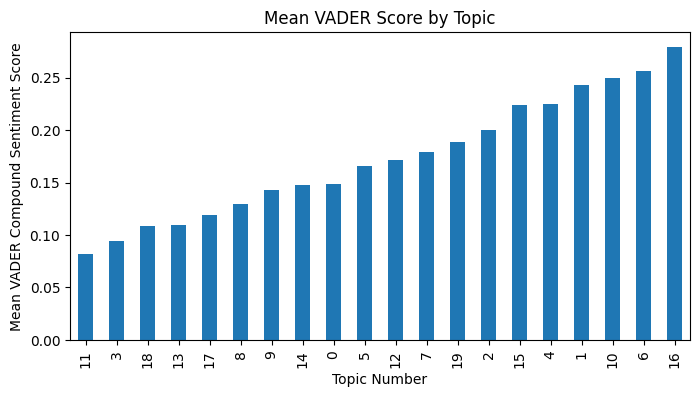

In [41]:
#Creates bar chart of topic number vs average Vader score
topic_sentiment = df_turns_copy_agg.groupby('topic')['compound_score_shifted'].mean().sort_values()

topic_sentiment.plot(kind='bar', figsize=(8,4), title='Mean VADER Score by Topic')
plt.ylabel('Mean VADER Compound Sentiment Score')
plt.xlabel('Topic Number')
plt.show()


In [42]:
#How many questions/turns are in each cluster
print('Number of turns in each cluster:\n', df_turns_copy_agg['topic'].value_counts())

Number of turns in each cluster:
 topic
17    23832
2      2512
9      2178
5      1497
0       870
12      835
19      794
3       725
14      712
8       659
4       609
6       588
11      562
18      478
15      469
7       421
16      402
1       341
10      314
13      214
Name: count, dtype: int64


In [43]:
#Mann-Whitney U Test to see if difference in VADER scores for topics is significant

topics = df_turns_copy_agg['topic'].unique()
results = []

#Iterate through each pair of topics
for i in range(len(topics)):
    for j in range(i + 1, len(topics)):
        topic1 = topics[i]
        topic2 = topics[j]

        #Find the compound scores
        scores1 = df_turns_copy_agg[df_turns_copy_agg['topic'] == topic1]['compound_score_shifted']
        scores2 = df_turns_copy_agg[df_turns_copy_agg['topic'] == topic2]['compound_score_shifted']

        # Perform Mann-Whitney U test
        u_statistic, p_value = stats.mannwhitneyu(scores1, scores2, alternative='two-sided')

        results.append({
            'topic1': topic1,
            'topic2': topic2,
            'u_stat': u_statistic,
            'p_val': p_value
        })

results_df = pd.DataFrame(results)
print("Pairwise Mann-Whitney U Test Results (unadjusted p-values):")
print(results_df.head())


Pairwise Mann-Whitney U Test Results (unadjusted p-values):
   topic1  topic2      u_stat         p_val
0      17       2  26435671.0  5.600772e-25
1      17       1   3391888.5  1.637091e-08
2      17      16   3799774.0  1.902670e-14
3      17       6   6031589.5  5.253480e-10
4      17      12   9320141.0  8.123257e-04


In [44]:
from statsmodels.stats.multitest import multipletests

# Adjust p-values for multiple comparisons
reject, pvals_corrected, _, _ = multipletests(results_df['p_val'], method='fdr_bh')
results_df['p_val_adj'] = pvals_corrected

print("Pairwise Mann-Whitney U Test Results (adjusted p-values):")
print(results_df.head())

Pairwise Mann-Whitney U Test Results (adjusted p-values):
   topic1  topic2      u_stat         p_val     p_val_adj
0      17       2  26435671.0  5.600772e-25  1.064147e-22
1      17       1   3391888.5  1.637091e-08  1.728040e-07
2      17      16   3799774.0  1.902670e-14  1.807537e-12
3      17       6   6031589.5  5.253480e-10  9.074193e-09
4      17      12   9320141.0  8.123257e-04  2.114272e-03


In [45]:
# Get all unique topics, sorted numerically for consistent matrix indexing
all_topics = sorted(df_turns_copy_agg['topic'].unique())

# Initialize a full matrix with NaNs for all combinations
full_p_values_matrix = pd.DataFrame(np.nan, index=all_topics, columns=all_topics)

# Populate the matrix with adjusted p-values
for t1 in all_topics:
    for t2 in all_topics:
        if t1 == t2:
          # A topic compared to itself has no difference
            full_p_values_matrix.loc[t1, t2] = 1.0
        else:
            # Find the p-value in results_df, considering topic1 and topic2 order doesn't matter for the test result
            # Find the entry where {topic1, topic2} matches {t1, t2}
            p_val_entry = results_df[((results_df['topic1'] == t1) & (results_df['topic2'] == t2)) |
                                     ((results_df['topic1'] == t2) & (results_df['topic2'] == t1))]

            if not p_val_entry.empty:
                # There should be only one such entry
                full_p_values_matrix.loc[t1, t2] = p_val_entry['p_val_adj'].iloc[0]

print("Adjusted P-value Matrix for Heatmap:")
print(full_p_values_matrix)

Adjusted P-value Matrix for Heatmap:
              0             1             2             3             4   \
0   1.000000e+00  4.733150e-04  2.330700e-04  7.900607e-02  2.619229e-03   
1   4.733150e-04  1.000000e+00  2.869017e-01  2.634240e-06  4.613059e-01   
2   2.330700e-04  2.869017e-01  1.000000e+00  1.453515e-07  9.226772e-01   
3   7.900607e-02  2.634240e-06  1.453515e-07  1.000000e+00  1.115823e-05   
4   2.619229e-03  4.613059e-01  9.226772e-01  1.115823e-05  1.000000e+00   
5   1.162912e-01  2.855753e-02  2.855753e-02  7.262011e-04  8.207951e-02   
6   2.590484e-04  6.670602e-01  1.616387e-01  9.038410e-07  3.617271e-01   
7   1.533335e-01  4.961808e-02  1.692647e-01  5.482366e-03  2.296411e-01   
8   9.580985e-01  2.885812e-04  5.306679e-04  1.292387e-01  4.157276e-03   
9   8.144360e-01  9.661015e-05  2.158216e-06  2.282482e-02  9.484950e-04   
10  8.207680e-06  7.002970e-01  5.675081e-02  7.294317e-08  9.541355e-02   
11  1.512170e-02  5.196557e-08  7.341529e-09  5.609

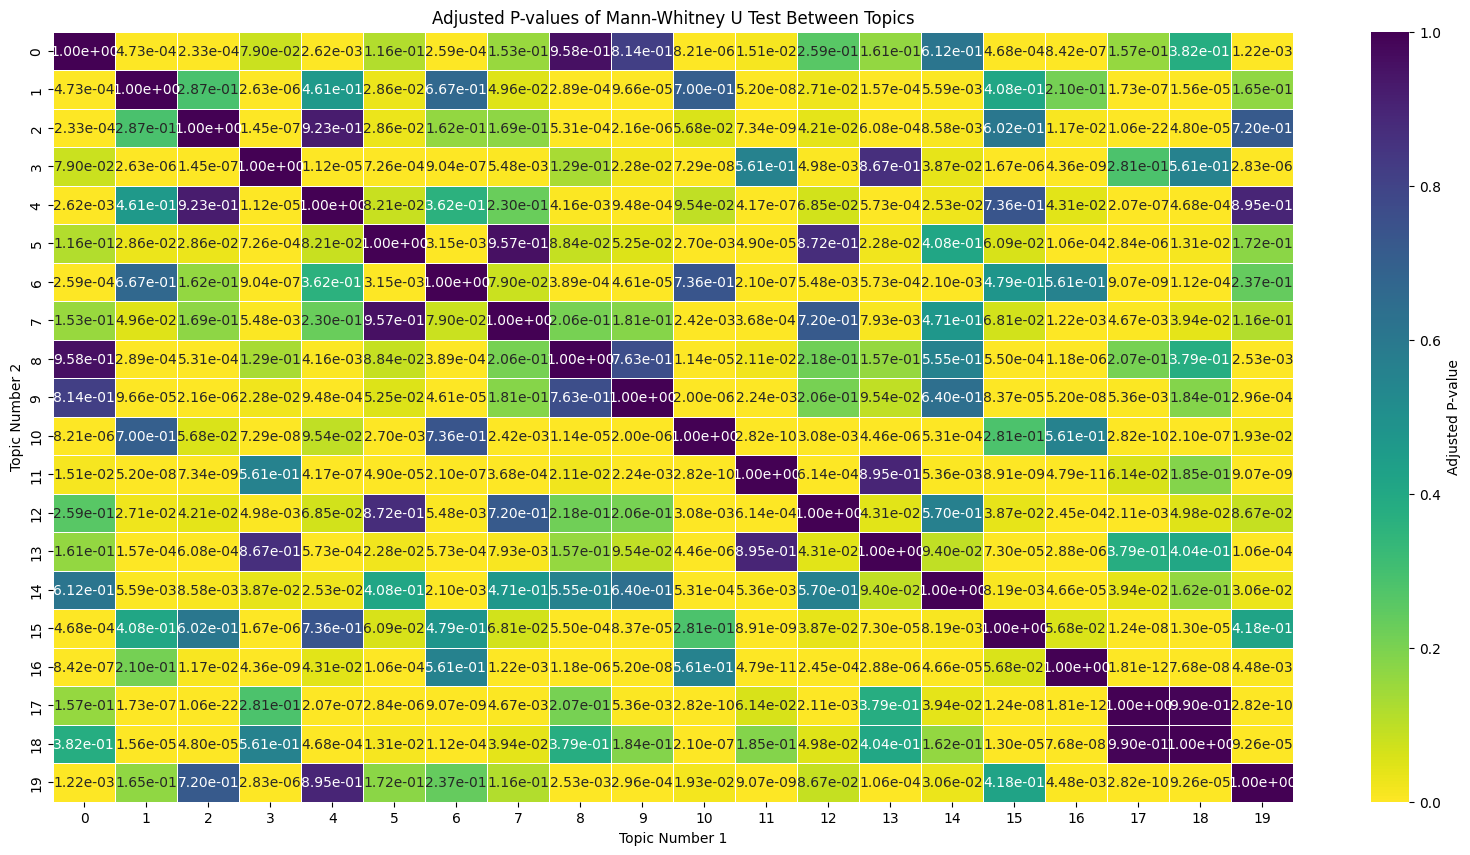

In [46]:
#Heatmap displaying statistical significance of difference in median VADER score for all topic numbers
plt.figure(figsize=(20, 10))
sns.heatmap(full_p_values_matrix, annot=True, cmap='viridis_r', fmt=".2e", linewidths=.5, cbar_kws={'label': 'Adjusted P-value'})
plt.title('Adjusted P-values of Mann-Whitney U Test Between Topics')
plt.xlabel('Topic Number 1')
plt.ylabel('Topic Number 2')
plt.show()